In [1]:
import numpy as np
from QKRR import SyntheticDataset, NumericalTestRisk, TheoreticalTestRisk

## Set common parameters across numerical and theoretical plots

In [2]:
N_QUBITS=5
LAMBDA_LIST=[1e-10, 1e-8, 1e-6, 1e-4, 1e-2]

rng_global = np.random.default_rng(42)
shared_true_params = rng_global.uniform(0, 2 * np.pi, size=(2 * N_QUBITS,))

synthetic_dataset = SyntheticDataset(N_QUBITS=N_QUBITS, train_size=60000, test_size=1000, noise_sigma=0.3)
X_train, y_train, X_test, y_test = synthetic_dataset.generate_dataset(true_params=shared_true_params)

## Numerical Test Risk

In [3]:
# REPS=30
# numerical_tester = NumericalTestRisk(N_QUBITS=N_QUBITS, LAMBDA_LIST=LAMBDA_LIST, REPS=REPS)

# # numerical_tester.numerical_test_risk_lambda(X_train, y_train, X_test, y_test)
# numerical_tester.numerical_test_risk_lambda_optimized(X_train, y_train, X_test, y_test)
# numerical_tester.save_results("results/QKRR_synthetic_5qubits_HEA_numerical.pkl")

In [4]:
numerical_tester = NumericalTestRisk(N_QUBITS=N_QUBITS, LAMBDA_LIST=LAMBDA_LIST)
numerical_tester.load_results("results/QKRR_synthetic_5qubits_HEA_numerical.pkl")

Training sample sizes: [640, 768, 896, 1024, 1152, 1280]


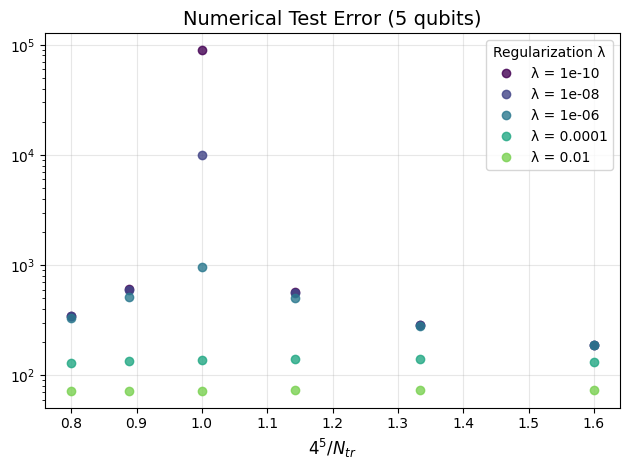

In [5]:
numerical_tester.plot_mse_test()

## Theoretical Test Risk

In [ ]:
# synthetic_dataset = SyntheticDataset(N_QUBITS=N_QUBITS, train_size=1, test_size=10000, noise_sigma=0.3)
# _, _, X_test_th, y_test_th = synthetic_dataset.generate_dataset(true_params=shared_true_params)

# theoretical_tester = TheoreticalTestRisk(N_QUBITS=N_QUBITS, LAMBDA_LIST=LAMBDA_LIST, noise_sigma=0.3)

# theoretical_tester.theoretical_test_risk_lambda(X_test_th, y_test_th)
# theoretical_tester.save_results("results/QKRR_synthetic_5qubits_HEA_theoretical.pkl")


λ = 1e-10
  n_train = 1284
λ = 1e-08
  n_train = 1284
λ = 1e-06
  n_train = 1284
λ = 0.0001
  n_train = 1284
λ = 0.01


In [7]:
theoretical_tester = TheoreticalTestRisk()
theoretical_tester.load_results("results/QKRR_synthetic_5qubits_HEA_theoretical.pkl")

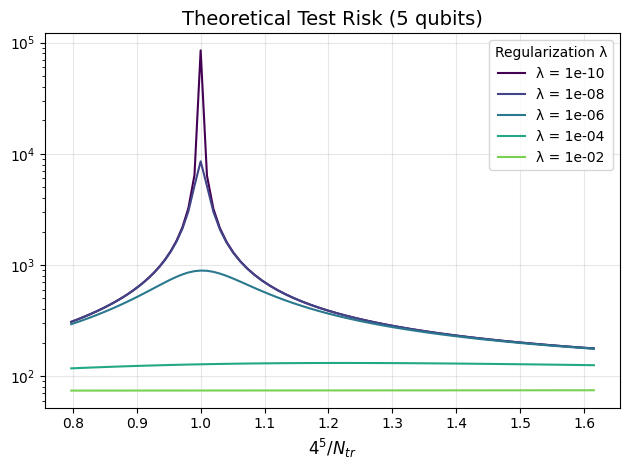

In [8]:
theoretical_tester.plot_theoretical_test()

In [9]:
# theoretical_tester.plot_effective_DOF()

<>:29: SyntaxWarning: invalid escape sequence '\g'
<>:29: SyntaxWarning: invalid escape sequence '\g'
/var/folders/9k/y9ch3jl55qd4kn1j6b53yyjw0000gn/T/ipykernel_39533/1994763943.py:29: SyntaxWarning: invalid escape sequence '\g'
  plt.xlabel(f'$\gamma = 4^{N_QUBITS}/N_{{tr}}$', fontsize=18)


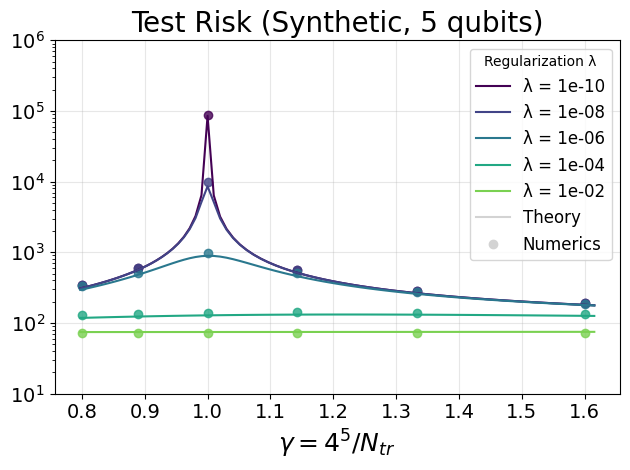

In [10]:
import numpy as np
import matplotlib.pyplot as plt

colors = plt.cm.viridis(np.linspace(0, 0.8, len(LAMBDA_LIST)))
numerical_ratio_list = 4 ** N_QUBITS / np.array(numerical_tester.n_train_list)
theoretical_ratio_list = 4 ** N_QUBITS / np.array(theoretical_tester.n_train_list)

for i, lam in enumerate(LAMBDA_LIST):
    plt.semilogy(
        numerical_ratio_list,
        numerical_tester.mse_test_all_mean[lam],
        marker='o',
        alpha=0.8,
        linestyle='none',
        color=colors[i]
    )

for i, lam in enumerate(LAMBDA_LIST):
    plt.semilogy(
        theoretical_ratio_list,
        theoretical_tester.R_theoretical_list[i],
        label=f'λ = {lam:.0e}',
        color=colors[i]
    )

plt.plot([], [], '-', color='lightgray', label='Theory')
plt.plot([], [], 'o', color='lightgray', label='Numerics')

plt.xlabel(f'$\gamma = 4^{N_QUBITS}/N_{{tr}}$', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(1e1, 1e6)
plt.title(f'Test Risk (Synthetic, {N_QUBITS} qubits)', fontsize=20)
plt.legend(title='Regularization λ', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'results/QKRR_synthetic_{N_QUBITS}qubits_HEA.pdf')